In [44]:
import numpy as np
import pandas as pd
import scipy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

In [45]:
df = pd.read_csv('cancer_classification.csv')

In [46]:
df.shape

(569, 31)

In [47]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [49]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
benign_0__mal_1            0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [52]:
df.corr()
#|correlation| ≥ 0.7 → Strong relationship (very important feature)

#0.5 ≤ |correlation| < 0.7 → Moderate relationship (useful feature)

#0.3 ≤ |correlation| < 0.5 → Weak but usable (optional)

#|correlation| < 0.3 → Very weak (usually less important)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


In [53]:
#  meanradius,mean perimeter ,mean area, mean compactness,mean concativity, mean concave value,worst parameter,arae,compactness,conacavity,concave point


<Axes: >

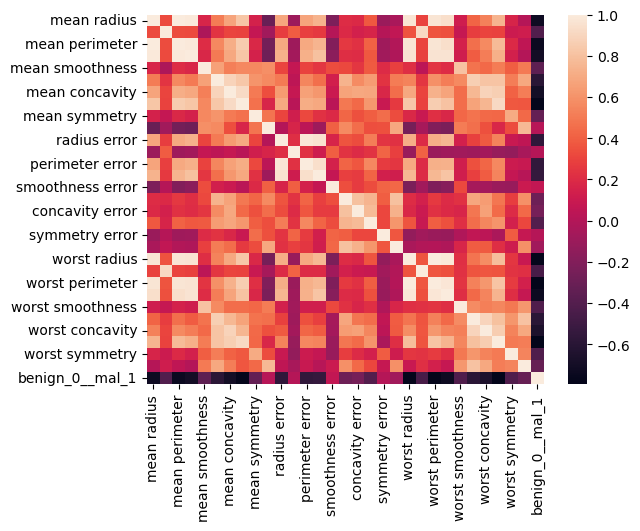

In [54]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix)


<Axes: >

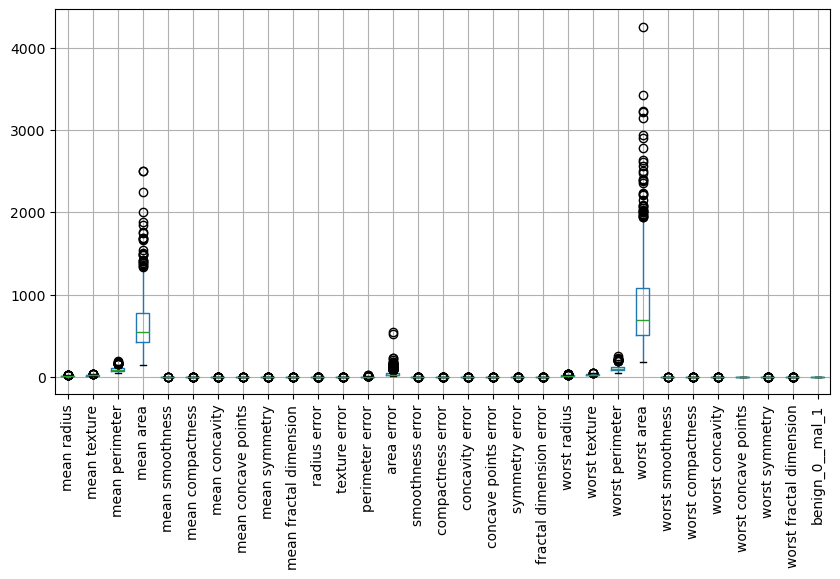

In [55]:
plt.figure(figsize=(10,5))  # Adjust size for many columns
df.boxplot(rot=90)     

In [56]:
df.skew()

mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150237
worst concave points       0

In [57]:
cols_to_transform = df.select_dtypes(include=['number']).columns.tolist()

for col in cols_to_transform:
    df[col] = np.log(df[col] + 1)

In [58]:
df.skew()

mean radius                0.348744
mean texture               0.018733
mean perimeter             0.328800
mean area                  0.287328
mean smoothness            0.406548
mean compactness           1.043195
mean concavity             1.206982
mean concave points        1.083180
mean symmetry              0.632718
mean fractal dimension     1.272294
radius error               1.713417
texture error              0.629526
perimeter error            1.025375
area error                 0.847298
smoothness error           2.283394
compactness error          1.816278
concavity error            4.231738
concave points error       1.399869
symmetry error             2.135874
fractal dimension error    3.874373
worst radius               0.506347
worst texture             -0.101178
worst perimeter            0.462758
worst area                 0.457614
worst smoothness           0.346313
worst compactness          1.048729
worst concavity            0.717939
worst concave points       0

<Axes: >

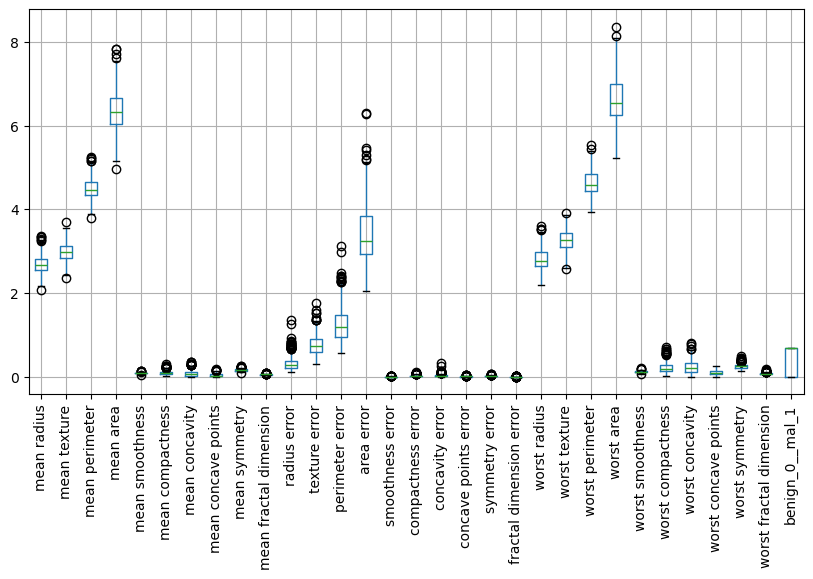

In [59]:
plt.figure(figsize=(10,5))  # Adjust size for many columns
df.boxplot(rot=90)  

In [60]:
# Initialize the scaler
scaler = MinMaxScaler()
df[cols_to_transform] = scaler.fit_transform(df[cols_to_transform])

In [61]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,0.669889,0.045807,0.704853,0.679091,0.605740,0.813663,0.738368,0.748616,0.703716,0.610784,...,0.252199,0.807199,0.761908,0.616837,0.695530,0.662222,0.921584,0.640921,0.435400,0.0
1,0.768335,0.423561,0.759224,0.777607,0.300320,0.203629,0.234445,0.369938,0.399431,0.144035,...,0.463405,0.713090,0.751782,0.362739,0.207492,0.266563,0.667873,0.268206,0.234858,0.0
2,0.736146,0.551956,0.744044,0.743495,0.526788,0.465372,0.506852,0.656539,0.530129,0.214963,...,0.524811,0.687799,0.708663,0.500112,0.470483,0.458033,0.851657,0.448280,0.225054,0.0
3,0.341761,0.521846,0.389719,0.345566,0.818820,0.831389,0.608382,0.545635,0.790129,1.000000,...,0.551288,0.417531,0.356830,0.920405,0.859276,0.644100,0.897064,1.000000,0.785235,0.0
4,0.758238,0.271225,0.770523,0.769858,0.442667,0.380177,0.508261,0.541191,0.397889,0.190206,...,0.225161,0.686569,0.682584,0.453711,0.229639,0.414467,0.589518,0.183681,0.151114,0.0


In [62]:
X = df.drop('benign_0__mal_1', axis=1)  ## axis 1 Horizontal (Columns)
y = df['benign_0__mal_1']

In [63]:
dtree = DecisionTreeClassifier(random_state=42)

In [64]:
rfe = RFE(estimator=dtree, n_features_to_select=5)

In [65]:
rfe.fit(X, y)

RFE(estimator=DecisionTreeClassifier(random_state=42), n_features_to_select=5)

In [66]:
selected_features = X.columns[rfe.support_].tolist() #This line identifies exactly which features the model decided were the most important.
feature_ranking = pd.DataFrame({ # This creates a neat table (DataFrame) to show you the "importance" of every single column.
    'Feature': X.columns,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking') # this sort new table 

print(f"Top 10 Selected Features:\n{selected_features}") # dissplay final table 
# Worst Radius (The Size)=#Easy Language: How big the center of the cell is.
#Worst Texture (The Interior)=Easy Language: How "messy" it looks inside.
#Worst Smoothness (The Edge)=Easy Language: How even the border is.
#Worst Concave Points (The Dents)=Easy Language: How many "dents" are in the shell.
# Worst Symmetry (The Balance)=Easy Language: Is the left side the same as the right side?

Top 10 Selected Features:
['worst radius', 'worst texture', 'worst smoothness', 'worst concave points', 'worst symmetry']


In [67]:
# Create the final reduced dataset
X_selected = X[selected_features]

# Optional: Add the target back if you want a complete dataframe
df_final = pd.concat([X_selected, y], axis=1)

print(f"New dataset shape: {df_final.shape}")

New dataset shape: (569, 6)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)
#This is the most important part for your dataset. In medical diagnosis
,# you want to make sure the percentage of "Malignant" cases is the same in both the training and testing sets.
#If you don't stratify, you might accidentally end up with a test set that has no cancer cases at all!

In [69]:
print(f"Training set size: {X_train.shape[0]} samples")

Training set size: 455 samples


In [70]:
print(f"Testing set size: {X_test.shape[0]} samples")

Testing set size: 114 samples


In [71]:
model = DecisionTreeClassifier(random_state=42)

In [72]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [73]:
y_pred = model.predict(X_test)

In [74]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")

Accuracy Score: 94.74%


In [75]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

#Class 1.0 (Malignant) – The Priority
#Recall (0.90): This is the most critical number. It means your model correctly identified 90% of the actual cancer cases. However, it missed 10%.
#In a medical context, missing 10% of cancer cases (False Negatives) is something doctors would want to improve.

#Precision (0.97): This is excellent. It means when your model says "This is Cancer," it is correct 97% of the time. 
#There are very few "False Alarms."

#Class 0.0 (Benign) – The Healthy Patients
#Recall (0.95): The model is very good at identifying healthy patients (95% accuracy for this group).

#Precision (0.85): This is lower because some patients the model flagged as "Benign" actually had cancer (the 10% missed from Class 1).



--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.91      0.95      0.93        42
         1.0       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [76]:
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
#False = actual ,Positives= predicted by model 
#True Negatives (40): The model correctly said "No Cancer." These people are safe.

#False Positives (2): The model said "Cancer," but they were actually healthy.
#This leads to unnecessary stress and extra tests (Biopsies), but it is not life-threatening.

#False Negatives (7): This is the danger zone. The model said "No Cancer," but the patient actually has it
#. These are the 7 people who might not get the treatment they need because the model missed them.

#True Positives (65): The model correctly identified the cancer.

--- Confusion Matrix ---
[[40  2]
 [ 4 68]]


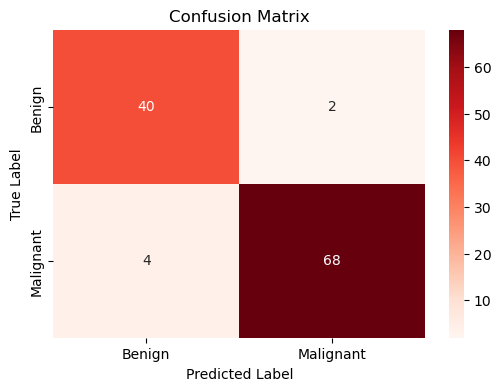

In [77]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [78]:

# To run it:
# predict_cancer_input(model, selected_features)
def predict_cancer_input(model, selected_features):
    print("--- Breast Cancer Prediction Tool ---")
    print(f"Please enter the following {len(selected_features)} measurements:")

In [79]:
user_data = []

In [81]:
    for feature in selected_features:
        # Ask user for each specific feature found by RFE
        val = float(input(f"Enter value for {feature}: "))
        user_data.append(val)
    
# Enter value for worst radius:  15.09
#Enter value for worst texture:  40.68
#Enter value for worst smoothness:  0.1853
#Enter value for worst concave points:  0.221
#Enter value for worst symmetry:  0.4366

Enter value for worst radius:  15.09
Enter value for worst texture:  40.68
Enter value for worst smoothness:  0.1853
Enter value for worst concave points:  0.221
Enter value for worst symmetry:  0.4366


In [85]:
# Convert list to a 2D array (required by sklearn)
    # We use a DataFrame so the model gets the feature names correctly
    # Convert list to a 2D array (required by sklearn)
    # We use a DataFrame so the model gets the feature names correctly
input_df = pd.DataFrame([user_data], columns=selected_features)


    
   
   


In [86]:
    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0] # Confidence level
    
    print("\n--- Result ---")
    if prediction == 1:
        print(f"Prediction: MALIGNANT (Confidence: {probability[1]:.2%})")
    else:
        print(f"Prediction: BENIGN (Confidence: {probability[0]:.2%})")


--- Result ---
Prediction: BENIGN (Confidence: 100.00%)
